### Импорты и настройка окружения

В этой ячейке подключаются библиотеки для обработки данных, работы с изображениями, построения моделей и обучения GAN. Здесь же формируется базовое окружение, на которое опираются все следующие этапы ноутбука.


In [ ]:
import os
import random
from pathlib import Path

import pandas as pd
import numpy as np
from torch.onnx.symbolic_opset9 import tensor
from torchvision import utils
import torch
from facenet_pytorch import MTCNN
import numpy as np
from pathlib import Path
from PIL import Image, ImageOps
from tqdm.auto import tqdm
import torchvision.transforms as T
from torch.utils.data import DataLoader
from dataset import CelebDS
from torch import optim
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore
import matplotlib.pyplot as plt

SEED = 32
EPS = 1e-8
lr_gen = 2e-4
lr_crit = 1e-4
betas = (0.0, 0.9)
lambda_gp = 10.0
n_critic = 1
epochs = 97

random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.mps.manual_seed(SEED)

attr = pd.read_csv(list_attr_celeba)
part = pd.read_csv(list_eval_partition)

df = part.merge(attr[["image_id", "Male"]], on="image_id", how="inner")

split_map = {0: "train", 1: "val", 2: "test"}
df["split"] = df["partition"].map(split_map)

df["male"] = (df["Male"] == 1).astype(int)
df = df.drop(columns=["Male"])

df["src_path"] = df["image_id"].apply(lambda x: str(imgs / x))


### Функции подготовки изображений

Здесь описаны вспомогательные функции для выбора лица на изображении, аккуратного кадрирования и подготовки квадратных кропов. Эти функции нужны, чтобы привести исходные фотографии к единому виду перед обучением.


In [ ]:
def pick_largest_face(boxes):
    areas = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
    return int(np.argmax(areas))


def crop_square_with_padding(img: Image.Image, box, out_size=128, expand=1.35, fill=(0, 0, 0)):
    w, h = img.size
    x1, y1, x2, y2 = map(float, box)

    cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
    bw, bh = (x2 - x1) * expand, (y2 - y1) * expand
    side = max(bw, bh)

    nx1, ny1 = cx - side / 2.0, cy - side / 2.0
    nx2, ny2 = cx + side / 2.0, cy + side / 2.0

    pad_l = max(0, int(np.floor(-nx1)))
    pad_t = max(0, int(np.floor(-ny1)))
    pad_r = max(0, int(np.ceil(nx2 - w)))
    pad_b = max(0, int(np.ceil(ny2 - h)))

    if pad_l or pad_t or pad_r or pad_b:
        img = ImageOps.expand(img, border=(pad_l, pad_t, pad_r, pad_b), fill=fill)
        nx1 += pad_l
        nx2 += pad_l
        ny1 += pad_t
        ny2 += pad_t

    nx1i, ny1i, nx2i, ny2i = map(lambda v: int(round(v)), (nx1, ny1, nx2, ny2))
    face = img.crop((nx1i, ny1i, nx2i, ny2i)).resize((out_size, out_size), Image.BILINEAR)
    return face, (nx1, ny1, nx2, ny2), (pad_l, pad_t, pad_r, pad_b)


def preprocess_dataset(out_root, df, image_size=128, expand=1.35, fill_color=(0, 0, 0)):
    mtcnn = MTCNN(
        image_size=image_size,
        margin=20,
        min_face_size=40,
        post_process=False,
        keep_all=False,
        device="cpu"
    )

    if out_root.exists():
        print(f"Already processed")
        return

    for s in ["train", "val", "test"]:
        (out_root / s).mkdir(parents=True)

    processed = 0
    failed = 0
    rows = []

    for i in tqdm(range(len(df))):
        row = df.loc[i]
        name = row["image_id"]
        split = row["split"]
        male = int(row["male"])
        src_path = Path(row["src_path"])
        out_path = out_root / split / name

        try:
            if not src_path.exists():
                failed += 1
                continue

            img = Image.open(src_path).convert("RGB")

            with torch.inference_mode():
                boxes, probs = mtcnn.detect(img)

            if boxes is None or len(boxes) == 0:
                failed += 1
                continue

            boxes = np.asarray(boxes, dtype=float)
            probs = np.asarray(probs, dtype=float) if probs is not None else None

            j = pick_largest_face(boxes)
            box = boxes[j]
            prob = float(probs[j]) if probs is not None else None

            face, crop_box, pads = crop_square_with_padding(
                img, box, out_size=image_size, expand=expand, fill=fill_color
            )

            face.save(out_path, quality=95)

            rows.append({
                "image_id": name,
                "split": split,
                "male": male,
                "prob": prob,
                "det_x1": box[0], "det_y1": box[1], "det_x2": box[2], "det_y2": box[3],
                "out_path": str(out_path)
            })
            processed += 1

        except Exception:
            failed += 1
            continue

    meta = pd.DataFrame(rows)
    meta.to_csv(out_root / "metadata.csv", index=False)
    print("processed:", processed, "failed:", failed)
    print("meta rows:", len(meta))

out_root = Path(f"processed")

DATA_SIZE = 50000
df_run = df.sample(DATA_SIZE, random_state=SEED).reset_index(drop=True)

### Предобработка датасета

Эта ячейка запускает полный пайплайн предобработки: чтение разметки, поиск лица, кроп, ресайз и сохранение результата. На выходе формируется готовый датасет и сопутствующая метаинформация.


In [ ]:
preprocess_dataset(out_root, df_run, image_size=128, expand=1.35, fill_color=(0, 0, 0))

Already processed


### Загрузка метаданных и разбиений

Здесь считывается таблица с метаданными и формируются выборки `train`, `val` и `test`. Это подготавливает основу для дальнейшего обучения и оценки моделей.


In [ ]:
metadata = pd.read_csv(out_root / "metadata.csv")
train_meta = metadata[metadata["split"] == "train"]
val_meta = metadata[metadata["split"] == "val"]
test_meta = metadata[metadata["split"] == "test"]

train_meta

,image_id,split,male,prob,det_x1,det_y1,det_x2,det_y2,out_path
0,085261.jpg,train,0,0.999139,46.780613,70.954010,128.389557,174.011322,processed/train/085261.jpg
1,135139.jpg,train,0,0.999978,40.751472,67.492432,132.265015,178.960007,processed/train/135139.jpg
2,061314.jpg,train,0,0.973098,50.530998,75.108902,130.091019,179.592056,processed/train/061314.jpg
3,128602.jpg,train,0,0.999881,50.203365,67.525047,131.993973,183.121643,processed/train/128602.jpg
4,158582.jpg,train,0,0.999931,50.125042,61.088173,136.645630,184.809235,processed/train/158582.jpg
...,...,...,...,...,...,...,...,...,...
49912,005730.jpg,train,0,0.999838,49.219589,70.538139,130.562302,178.951889,processed/train/005730.jpg
49913,151277.jpg,train,0,0.999609,57.018959,72.679611,133.981995,176.486298,processed/train/151277.jpg
49914,069464.jpg,train,0,0.999336,54.476357,62.185242,141.891098,179.109177,processed/train/069464.jpg
49915,135287.jpg,train,1,0.999999,73.373734,76.749451,153.782181,185.826904,processed/train/135287.jpg


### Визуальная проверка подготовленных данных

В этой ячейке случайные изображения из датасета выводятся в виде сетки. Такой просмотр нужен, чтобы быстро убедиться, что предобработка прошла корректно и метки выглядят правдоподобно.


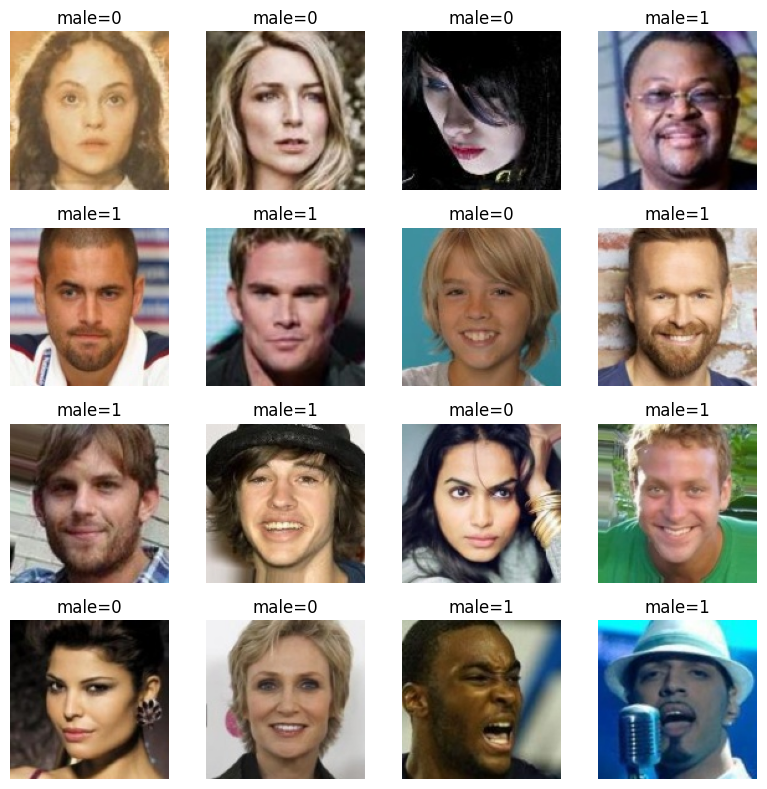

In [ ]:
sample = metadata.sample(16, random_state=0)

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for ax, (_, r) in zip(axes.flatten(), sample.iterrows()):
    im = Image.open(r["out_path"]).convert("RGB")
    ax.imshow(im)
    ax.set_title(f"male={int(r['male'])}")
    ax.axis("off")
plt.tight_layout()
plt.show()


### GAN для задачи безусловной генерации

### Трансформации изображений

Здесь задаются преобразования, применяемые к изображениям перед подачей в модель. Основная цель этой ячейки — перевести картинки в тензоры и нормализовать значения пикселей.


In [ ]:
transform = T.Compose([
    T.ToTensor(),
    T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])


### DataLoader для безусловной модели

В этой ячейке создаются датасеты и загрузчики батчей для безусловной генерации. Также настраиваются параметры пакетной загрузки, влияющие на скорость и стабильность обучения.


In [13]:
batch_size = 64
num_workers = 8
prefetch_factor = 8

train_ds = CelebDS(train_meta, transform=transform, conditional=False)
val_ds = CelebDS(val_meta, transform=transform, conditional=False)

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=False,
    drop_last=True,
    prefetch_factor=prefetch_factor,
    persistent_workers=False,
)

val_loader = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=False,
    drop_last=False,
    prefetch_factor=prefetch_factor,
    persistent_workers=False,
)


### Архитектура генератора и критика

Здесь задаётся инициализация весов, а также классы `Generator` и `Critic`. Эти модели составляют основу WGAN-GP и поддерживают как безусловный, так и условный режим работы.


In [ ]:
def weights_init(m):
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d, nn.Linear)):
        nn.init.normal_(m.weight, 0.0, 0.02)
        if getattr(m, "bias", None) is not None:
            nn.init.constant_(m.bias, 0)


class Generator(nn.Module):
    def __init__(self, z_dim=128, ngf=64, out_ch=3, y_dim=None, y_emb_dim=32):
        super().__init__()

        self.z_dim = z_dim
        self.y_dim = y_dim
        self.y_emb_dim = y_emb_dim if y_dim is not None else 0

        if y_dim is not None:
            self.y_emb = nn.Embedding(y_dim, y_emb_dim)
        else:
            self.y_emb = None

        in_ch = z_dim + self.y_emb_dim

        self.net = nn.Sequential(
            nn.ConvTranspose2d(in_ch, ngf * 16, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 16),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 16, ngf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf, out_ch, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z, y=None):
        if self.y_emb is not None:
            yv = self.y_emb(y).unsqueeze(-1).unsqueeze(-1)
            inp = torch.cat([z, yv], dim=1)
        else:
            inp = z
        return self.net(inp)


class Critic(nn.Module):
    def __init__(self, ndf=64, in_ch=3, y_dim=None):
        super().__init__()
        self.y_dim = y_dim

        def block(cin, cout, norm=True):
            layers = [nn.Conv2d(cin, cout, 4, 2, 1, bias=False)]
            if norm:
                g = min(32, cout)
                layers += [nn.GroupNorm(g, cout)]
            layers += [nn.LeakyReLU(0.2, inplace=True)]
            return nn.Sequential(*layers)

        self.net = nn.Sequential(
            block(in_ch, ndf, norm=False),
            block(ndf, ndf * 2, norm=True),
            block(ndf * 2, ndf * 4, norm=True),
            block(ndf * 4, ndf * 8, norm=True),
            block(ndf * 8, ndf * 16, norm=True),
            nn.Conv2d(ndf * 16, 1, 4, 1, 0, bias=False),
        )

        self.feat_dim = ndf * 16
        self.y_emb = nn.Embedding(y_dim, self.feat_dim) if y_dim is not None else None

    def forward(self, x, y=None):
        if self.y_emb is None:
            return self.net(x).view(x.size(0))

        h = self.net[:-1](x)
        out = self.net[-1](h).view(x.size(0))

        if y is None:
            raise ValueError("Conditional Critic requires y")

        h_vec = h.sum(dim=(2, 3))
        proj = (self.y_emb(y) * h_vec).sum(dim=1)
        return out + proj


### Инициализация безусловной GAN

Эта ячейка создаёт экземпляры генератора и критика для безусловной постановки и переносит их на устройство вычислений. После этого к моделям применяется инициализация весов. Здесь создаются оптимизаторы, фиксированный шум для мониторинга качества, а также директории для сэмплов и чекпоинтов. Ячейка подготавливает всё необходимое для сохранения прогресса обучения.


In [ ]:
generator = Generator(z_dim=128, ngf=64).to("mps")
critic = Critic(ndf=64).to("mps")

generator.apply(weights_init)
critic.apply(weights_init)

opt_gen = optim.Adam(generator.parameters(), lr=lr_gen, betas=betas)
opt_crit = optim.Adam(critic.parameters(), lr=lr_crit, betas=betas)

fixed_z = torch.randn(64, 128, 1, 1, device="mps")

model_root = Path("model")
samples_dir = model_root / "samples_wgan_gp"
ckpt_dir = model_root / "checkpoints_wgan_gp"
samples_dir.mkdir(parents=True, exist_ok=True)
ckpt_dir.mkdir(parents=True, exist_ok=True)
ckpt_last = ckpt_dir / "last.pt"


### Сохранение сэмплов и чекпоинтов

В этой ячейке определяются сервисные функции для сохранения сгенерированных изображений и состояния обучения. Это позволяет отслеживать динамику качества и при необходимости продолжать обучение с последней точки.


In [ ]:
def save_samples(generator, z, path, y=None):
    generator.eval()
    with torch.inference_mode():
        fake = generator(z, y).detach().cpu()
        fake = (fake * 0.5 + 0.5).clamp(0, 1)
        grid = utils.make_grid(fake, nrow=8)
        utils.save_image(grid, path)
    generator.train()


def save_last_checkpoint(path, epoch, step, generator, critic, opt_gen, opt_crit, losses, metrics):
    tmp = path.with_suffix(".tmp")
    torch.save({
        "epoch": epoch,
        "step": step,
        "generator": generator.state_dict(),
        "critic": critic.state_dict(),
        "opt_gen": opt_gen.state_dict(),
        "opt_crit": opt_crit.state_dict(),
        "losses": losses,
        "metrics": metrics
    }, tmp)
    tmp.replace(path)


def optimizer_to_device(optimizer, device):
    for state in optimizer.state.values():
        for k, v in state.items():
            if torch.is_tensor(v):
                state[k] = v.to(device)


losses = {"crit": [], "gen": [], "wass": [], "gp": []}
metrics = {"epoch": [], "fid": [], "is_mean": [], "is_std": [], "n": []}
step = 0

if ckpt_last.exists():
    ckpt = torch.load(ckpt_last, map_location="cpu")

    generator.load_state_dict(ckpt["generator"])
    critic.load_state_dict(ckpt["critic"])
    opt_gen.load_state_dict(ckpt["opt_gen"])
    opt_crit.load_state_dict(ckpt["opt_crit"])

    losses = ckpt.get("losses", losses)
    metrics = ckpt.get("metrics", metrics)
    step = int(ckpt.get("step", 0))
    last_epoch = int(ckpt.get("epoch", 0))
    start_epoch = last_epoch + 1

    print(f"epoch={last_epoch}, step={step}")
else:
    start_epoch = 1

optimizer_to_device(opt_gen, "mps")
optimizer_to_device(opt_crit, "mps")

### Подготовка вычисления FID

Здесь описываются вспомогательные функции для перевода изображений в нужный диапазон и накопления статистик реальных данных. Эти статистики затем используются для оценки качества генерации через FID.


In [ ]:
fid_state_path = model_root / "fid.pt"


def to_01(x):
    return (x.clamp(-1, 1) + 1) / 2


def prepare_fid(
        val_loader,
        fid_metric,
        max_real=5000
):
    fid_metric.reset()
    n_seen = 0

    for real in val_loader:
        if isinstance(real, (tuple, list)):
            real = real[0]

        real_01 = to_01(real).to("cpu", dtype=torch.float32)
        fid_metric.update(real_01, real=True)

        n_seen += real_01.size(0)
        if n_seen >= max_real:
            break

    n_real = int(fid_metric.real_features_num_samples.item()
                 if torch.is_tensor(fid_metric.real_features_num_samples)
                 else fid_metric.real_features_num_samples)

    pack = {
        "n_real": n_real,
        "real_features_sum": fid_metric.real_features_sum.detach().cpu(),
        "real_features_cov_sum": fid_metric.real_features_cov_sum.detach().cpu(),
        "real_features_num_samples": fid_metric.real_features_num_samples.detach().cpu()
        if torch.is_tensor(fid_metric.real_features_num_samples)
        else torch.tensor(n_real, dtype=torch.long),
    }
    torch.save(pack, fid_state_path)
    return n_real


@torch.inference_mode()
def compute_fid_is(
        generator,
        fid_metric,
        is_metric,
        z_dim=128,
        batch_size_fake=64
):
    generator.eval()

    fid_metric.reset()

    pack = torch.load(fid_state_path, map_location="cpu")
    n_real = int(pack["n_real"])

    fid_metric.real_features_sum.copy_(pack["real_features_sum"])
    fid_metric.real_features_cov_sum.copy_(pack["real_features_cov_sum"])

    if torch.is_tensor(fid_metric.real_features_num_samples):
        fid_metric.real_features_num_samples.copy_(pack["real_features_num_samples"])
    else:
        fid_metric.real_features_num_samples = int(pack["real_features_num_samples"].item())

    is_metric.reset()

    n_fake = 0
    while n_fake < n_real:
        b = min(batch_size_fake, n_real - n_fake)
        z = torch.randn(b, z_dim, 1, 1, device="mps")
        fake = generator(z)
        fake_01 = to_01(fake).to("cpu")

        fid_metric.update(fake_01, real=False)
        is_metric.update(fake_01)

        n_fake += b

    fid = float(fid_metric.compute().item())
    is_mean, is_std = is_metric.compute()
    is_mean = float(is_mean.item())
    is_std = float(is_std.item())

    generator.train()
    return fid, is_mean, is_std, n_real


### Инициализация метрик качества

В этой ячейке создаются объекты метрик `FID` и `Inception Score`. Они будут использоваться для количественной оценки качества и разнообразия сгенерированных изображений.


In [21]:
fid_metric = FrechetInceptionDistance(feature=2048, normalize=True).to("cpu")
is_metric = InceptionScore(normalize=True, splits=10).to("cpu")

/Users/mmarles/computer-vision/cv-hw4/.venv/lib/python3.11/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


### Кэширование признаков реальных изображений

Здесь проверяется, были ли уже заранее посчитаны признаки реальных изображений для FID. Если нет, они вычисляются один раз и сохраняются, чтобы не повторять дорогую операцию.


In [22]:
n_real = 128
if not fid_state_path.exists():
    prepare_fid(val_loader, fid_metric, max_real=n_real)


### Gradient Penalty и цикл обучения WGAN-GP

В этой ячейке реализуется штраф на норму градиента и основной цикл обучения безусловной модели. Здесь обновляются критик и генератор, сохраняются метрики и промежуточные результаты.


In [ ]:
def gradient_penalty(critic, real, fake, y=None, lambda_gp=10.0):
    b = real.size(0)
    eps = torch.rand(b, 1, 1, 1, device="mps")
    x_hat = eps * real + (1 - eps) * fake
    x_hat.requires_grad_(True)

    if y is not None:
        d_hat = critic(x_hat, y)
    else:
        d_hat = critic(x_hat)

    grad_outputs = torch.ones_like(d_hat, device="mps")

    grads = torch.autograd.grad(
        outputs=d_hat,
        inputs=x_hat,
        grad_outputs=grad_outputs,
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]

    grads = grads.view(b, -1)
    gp = ((grads.norm(2, dim=1) - 1.0) ** 2).mean() * lambda_gp
    return gp

for epoch in range(start_epoch, epochs + 1):
    for real in train_loader:
        step += 1

        real = real.to("mps")
        b = real.size(0)

        for _ in range(n_critic):
            z = torch.randn(b, 128, 1, 1, device="mps")
            fake = generator(z).detach()

            crit_real = critic(real).mean()
            crit_fake = critic(fake).mean()
            wass_dist = crit_real - crit_fake

            gp_interval = 4
            if step % gp_interval == 0:
                gp = gradient_penalty(critic, real, fake, lambda_gp=lambda_gp * gp_interval)
            else:
                gp = torch.tensor(0).to("mps")

            loss_critic = -wass_dist + gp

            opt_crit.zero_grad(set_to_none=True)
            loss_critic.backward()
            opt_crit.step()

        z = torch.randn(b, 128, 1, 1, device="mps")
        fake = generator(z)
        loss_gen = -critic(fake).mean()

        opt_gen.zero_grad(set_to_none=True)
        loss_gen.backward()
        opt_gen.step()

        losses["crit"].append(loss_critic.item())
        losses["gen"].append(loss_gen.item())
        losses["wass"].append(wass_dist.item())
        losses["gp"].append(gp.item())

        if step % 300 == 0:
            save_samples(generator, fixed_z, samples_dir / f"step_{step:07d}.png")
            print(
                f"epoch {epoch} step {step} | loss_crit {loss_critic.item():.3f} | loss_gen {loss_gen.item():.3f} | wass {wass_dist.item():.3f} | gp {gp.item():.3f} | crit_real {crit_real.item():.3f} | crit_fake {crit_fake.item():.3f}")

    fid, is_mean, is_std, n = compute_fid_is(generator, fid_metric, is_metric, z_dim=128)
    metrics["epoch"].append(epoch)
    metrics["fid"].append(fid)
    metrics["is_mean"].append(is_mean)
    metrics["is_std"].append(is_std)
    metrics["n"].append(n)
    print(f"[metrics] epoch {epoch} | FID {fid:.2f} | IS {is_mean:.2f}±{is_std:.2f} | n={n}")
    save_last_checkpoint(ckpt_last, epoch, step, generator, critic, opt_gen, opt_crit, losses, metrics)

    save_samples(generator, fixed_z, samples_dir / f"epoch_{epoch:03d}.png")


### Условная генерация

### DataLoader для условной генерации

Здесь подготавливаются датасеты и загрузчики для условной модели, где вместе с изображением используется метка класса. Это позволяет обучать генератор управляемой генерации по атрибуту.


In [24]:
batch_size = 64
num_workers = 0  #8
prefetch_factor = None  #8

cond_train_ds = CelebDS(train_meta, transform=transform, conditional=True)
cond_val_ds = CelebDS(val_meta, transform=transform, conditional=True)

cond_train_loader = DataLoader(
    cond_train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=False,
    drop_last=True,
    prefetch_factor=prefetch_factor,
    persistent_workers=False,  # todo true
)

cond_val_loader = DataLoader(
    cond_val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=False,
    drop_last=False,
    prefetch_factor=prefetch_factor,
    persistent_workers=False,
)


### Инициализация условной GAN

В этой ячейке создаются условные версии генератора и критика, учитывающие метку класса. После создания модели также инициализируются случайными весами.


In [25]:
cond_generator = Generator(z_dim=128, ngf=64, y_dim=2, y_emb_dim=32).to("mps")
cond_critic = Critic(ndf=64, y_dim=2).to("mps")

cond_generator.apply(weights_init)
cond_critic.apply(weights_init)


Critic(
  (net): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (1): LeakyReLU(negative_slope=0.2, inplace=True)
    )
    (1): Sequential(
      (0): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (1): GroupNorm(32, 128, eps=1e-05, affine=True)
      (2): LeakyReLU(negative_slope=0.2, inplace=True)
    )
    (2): Sequential(
      (0): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (1): GroupNorm(32, 256, eps=1e-05, affine=True)
      (2): LeakyReLU(negative_slope=0.2, inplace=True)
    )
    (3): Sequential(
      (0): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (1): GroupNorm(32, 512, eps=1e-05, affine=True)
      (2): LeakyReLU(negative_slope=0.2, inplace=True)
    )
    (4): Sequential(
      (0): Conv2d(512, 1024, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (1

### Оптимизаторы и артефакты условной модели

Здесь настраиваются оптимизаторы, пути для чекпоинтов и примеров, а также фиксированные значения шума и меток. Это нужно для стабильного мониторинга условной генерации во время обучения.


In [ ]:
cond_opt_gen = optim.Adam(cond_generator.parameters(), lr=lr_gen, betas=betas)
cond_opt_crit = optim.Adam(cond_critic.parameters(), lr=lr_crit, betas=betas)

model_root = Path("model")
cond_samples_dir = model_root / "samples_wgan_gp_cond"
ckpt_dir = model_root / "checkpoints_wgan_gp_cond"
cond_samples_dir.mkdir(parents=True, exist_ok=True)
ckpt_dir.mkdir(parents=True, exist_ok=True)
cond_ckpt_last = ckpt_dir / "last.pt"

fixed_z = torch.randn(64, 128, 1, 1, device="mps")
fixed_y = torch.tensor([0] * 32 + [1] * 32, device="mps")

### Восстановление обучения условной модели

В этой ячейке инициализируются словари для лоссов и метрик, а затем при наличии чекпоинта восстанавливается состояние обучения. Это позволяет не начинать тренировку заново после остановки.


In [28]:
cond_losses = {"crit": [], "gen": [], "wass": [], "gp": []}
cond_metrics = {"epoch": [], "fid": [], "is_mean": [], "is_std": [], "n": []}
step = 0

if cond_ckpt_last.exists():
    print("чекпоинт", cond_ckpt_last)
    ckpt = torch.load(cond_ckpt_last, map_location="cpu")

    cond_generator.load_state_dict(ckpt["generator"])
    cond_critic.load_state_dict(ckpt["critic"])
    cond_opt_gen.load_state_dict(ckpt["opt_gen"])
    cond_opt_crit.load_state_dict(ckpt["opt_crit"])

    cond_losses = ckpt.get("losses", cond_losses)
    cond_metrics = ckpt.get("metrics", cond_metrics)
    step = int(ckpt.get("step", 0))
    last_epoch = int(ckpt.get("epoch", 0))
    start_epoch = last_epoch + 1

    print(f"epoch={last_epoch}, step={step}")
else:
    start_epoch = 1
    ckpt = torch.load(ckpt_last, map_location="cpu")
    res = cond_critic.load_state_dict(ckpt["critic"], strict=False)
    print("critic missing:", res.missing_keys[:10], "total:", len(res.missing_keys))
    print("critic unexpected:", res.unexpected_keys[:10], "total:", len(res.unexpected_keys))


    def load_by_shape(model, sd):
        msd = model.state_dict()
        copied, skipped = 0, 0
        for k, v in sd.items():
            if k in msd and msd[k].shape == v.shape:
                msd[k].copy_(v)
                copied += 1
            else:
                skipped += 1
        model.load_state_dict(msd)
        return copied, skipped


    copied, skipped = load_by_shape(cond_generator, ckpt["generator"])
    print("gen copied:", copied, "skipped:", skipped)

optimizer_to_device(cond_opt_gen, "mps")
optimizer_to_device(cond_opt_crit, "mps")

чекпоинт model/checkpoints_wgan_gp_cond/last.pt
epoch=76, step=39501


### Метрики для условной генерации

Здесь создаются отдельные экземпляры `FID` и `Inception Score` для условной модели. Так оценки безусловного и условного вариантов не смешиваются между собой.


In [ ]:
cond_fid_state_path = model_root / "fid_cond.pt"
cond_fid_metric = FrechetInceptionDistance(feature=2048, normalize=True).to("cpu")
cond_is_metric = InceptionScore(normalize=True, splits=1).to("cpu")


### Подготовка реальных признаков для условного FID

В этой ячейке реализована функция, которая накапливает признаки реальных изображений для вычисления FID в условной постановке. Дополнительно результат сохраняется в файл для повторного использования.


In [ ]:
def prepare_fid_real_cond(val_loader, fid_metric, state_path, max_real=128):
    fid_metric.reset()
    n_seen = 0

    for real in val_loader:
        if isinstance(real, (tuple, list)):
            real = real[0]

        real_01 = to_01(real).to("cpu", dtype=torch.float32)
        fid_metric.update(real_01, real=True)

        n_seen += real_01.size(0)
        if n_seen >= max_real:
            break

    n_real = int(fid_metric.real_features_num_samples.item()
                 if torch.is_tensor(fid_metric.real_features_num_samples)
                 else fid_metric.real_features_num_samples)

    pack = {
        "n_real": n_real,
        "real_features_sum": fid_metric.real_features_sum.detach().cpu(),
        "real_features_cov_sum": fid_metric.real_features_cov_sum.detach().cpu(),
        "real_features_num_samples": fid_metric.real_features_num_samples.detach().cpu()
        if torch.is_tensor(fid_metric.real_features_num_samples)
        else torch.tensor(n_real, dtype=torch.long),
    }
    torch.save(pack, state_path)
    print(f"[prepare_fid_real_cond] saved n_real={n_real} to {state_path}")
    return n_real

@torch.inference_mode()
def compute_fid_is_cond(
        generator,
        fid_metric,
        is_metric,
        state_path,
        z_dim=128,
        batch_size_fake=64
):
    generator.eval()

    fid_metric.reset()
    is_metric.reset()

    pack = torch.load(state_path, map_location="cpu")
    n_real = int(pack["n_real"])

    fid_metric.real_features_sum.copy_(pack["real_features_sum"])
    fid_metric.real_features_cov_sum.copy_(pack["real_features_cov_sum"])
    if torch.is_tensor(fid_metric.real_features_num_samples):
        fid_metric.real_features_num_samples.copy_(pack["real_features_num_samples"])
    else:
        fid_metric.real_features_num_samples = int(pack["real_features_num_samples"].item())

    n_fake = 0
    while n_fake < n_real:
        b = min(batch_size_fake, n_real - n_fake)
        z = torch.randn(b, z_dim, 1, 1, device="mps")
        y_fake = torch.randint(0, 2, (b,), device="mps")
        fake = generator(z, y_fake)
        fake_01 = to_01(fake).to("cpu")

        fid_metric.update(fake_01, real=False)
        is_metric.update(fake_01)

        n_fake += b

    fid = float(fid_metric.compute().item())
    is_mean, is_std = is_metric.compute()

    generator.train()

    return fid, float(is_mean.item()), float(is_std.item()), n_real


n_real_cond = 256
if not cond_fid_state_path.exists():
    prepare_fid_real_cond(cond_val_loader, cond_fid_metric, cond_fid_state_path, max_real=n_real_cond)


### Обучение условного WGAN-GP

Здесь расположен основной цикл обучения условной модели. На каждом шаге генератор и критик обновляются с учётом метки класса, а также периодически считаются метрики и сохраняются результаты.


In [ ]:
cond_epochs = 70

for epoch in range(start_epoch, cond_epochs + 1):
    for real, y in cond_train_loader:
        step += 1

        real = real.to("mps")
        y = y.to("mps")
        b = real.size(0)

        for _ in range(n_critic):
            z = torch.randn(b, 128, 1, 1, device="mps")
            fake = cond_generator(z, y).detach()

            crit_real = cond_critic(real, y).mean()
            crit_fake = cond_critic(fake, y).mean()
            wass_dist = crit_real - crit_fake

            if step % 4 == 0:
                gp = gradient_penalty(cond_critic, real, fake, y=y, lambda_gp=lambda_gp * 4)
            else:
                gp = torch.zeros((), device="mps")

            loss_crit = -wass_dist + gp

            cond_opt_crit.zero_grad(set_to_none=True)
            loss_crit.backward()
            cond_opt_crit.step()

        z = torch.randn(b, 128, 1, 1, device="mps")
        y_fake = torch.randint(0, 2, (b,), device="mps")
        fake = cond_generator(z, y_fake)
        loss_gen = -cond_critic(fake, y_fake).mean()

        cond_opt_gen.zero_grad(set_to_none=True)
        loss_gen.backward()
        cond_opt_gen.step()

        cond_losses["crit"].append(loss_crit.item())
        cond_losses["gen"].append(loss_gen.item())
        cond_losses["wass"].append(wass_dist.item())
        cond_losses["gp"].append(gp.item())

        if step % 100 == 0:
            save_samples(cond_generator, fixed_z, cond_samples_dir / f"step_{step:07d}.png", y=fixed_y)
            print(
                f"epoch {epoch} step {step} | loss_crit {loss_crit.item():.3f} | loss_gen {loss_gen.item():.3f} | wass {wass_dist.item():.3f} | gp {gp.item():.3f} | crit_real {crit_real.item():.3f} | crit_fake {crit_fake.item():.3f}")

    save_samples(cond_generator, fixed_z, cond_samples_dir / f"epoch_{epoch:03d}.png", y=fixed_y)

    fid, is_mean, is_std, n = compute_fid_is_cond(
        cond_generator,
        cond_fid_metric,
        cond_is_metric,
        cond_fid_state_path,
        z_dim=128,
        batch_size_fake=64
    )

    cond_metrics["epoch"].append(epoch)
    cond_metrics["fid"].append(fid)
    cond_metrics["is_mean"].append(is_mean)
    cond_metrics["is_std"].append(is_std)
    cond_metrics["n"].append(n)

    print(f"[cond metrics] epoch {epoch} | FID {fid:.2f} | IS {is_mean:.2f}±{is_std:.2f} | n={n}")

    save_last_checkpoint(
        cond_ckpt_last,
        epoch,
        step,
        cond_generator,
        cond_critic,
        cond_opt_gen,
        cond_opt_crit,
        cond_losses,
        cond_metrics
    )



### Графики для безусловной модели

Здесь строятся графики лоссов и метрик для безусловного генератора. По ним можно оценить устойчивость обучения и изменение качества генерации по эпохам.


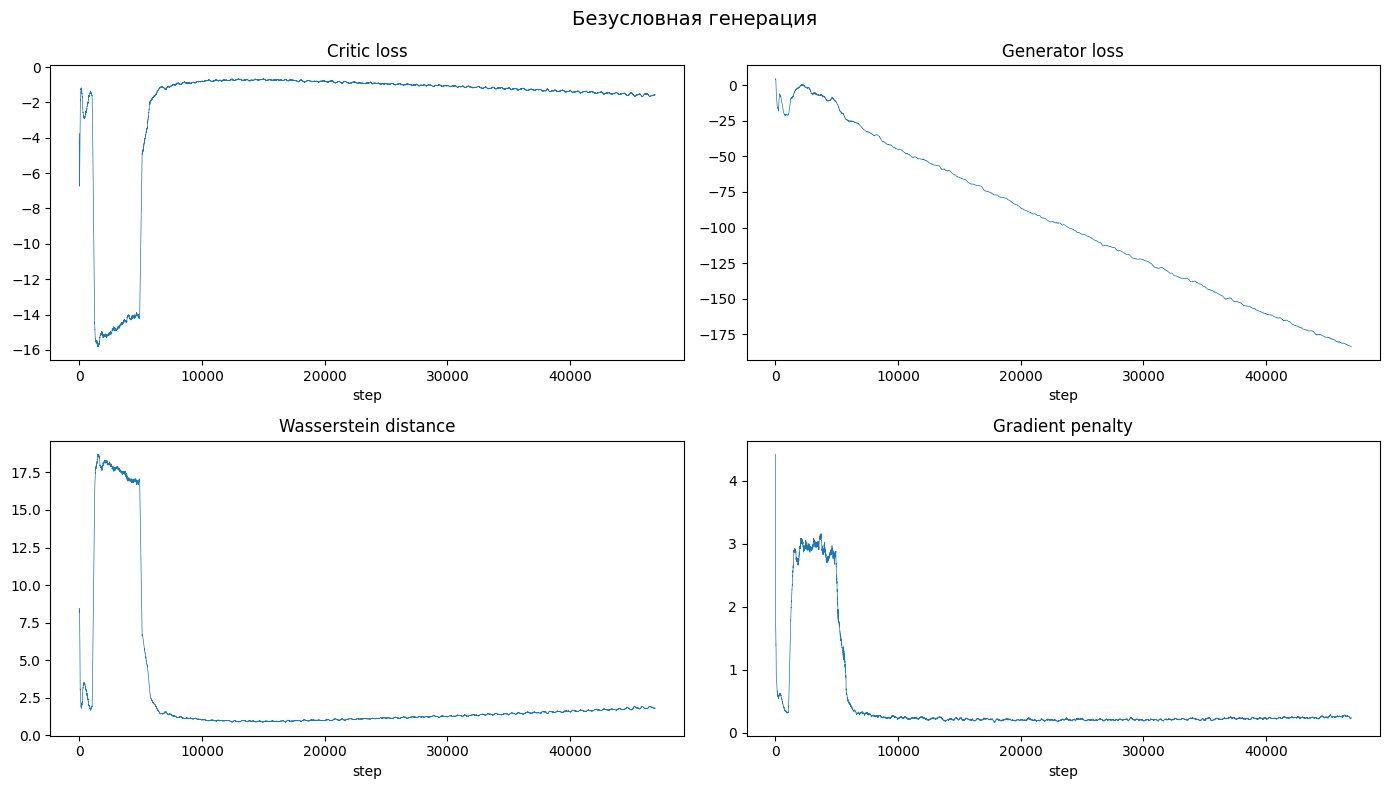

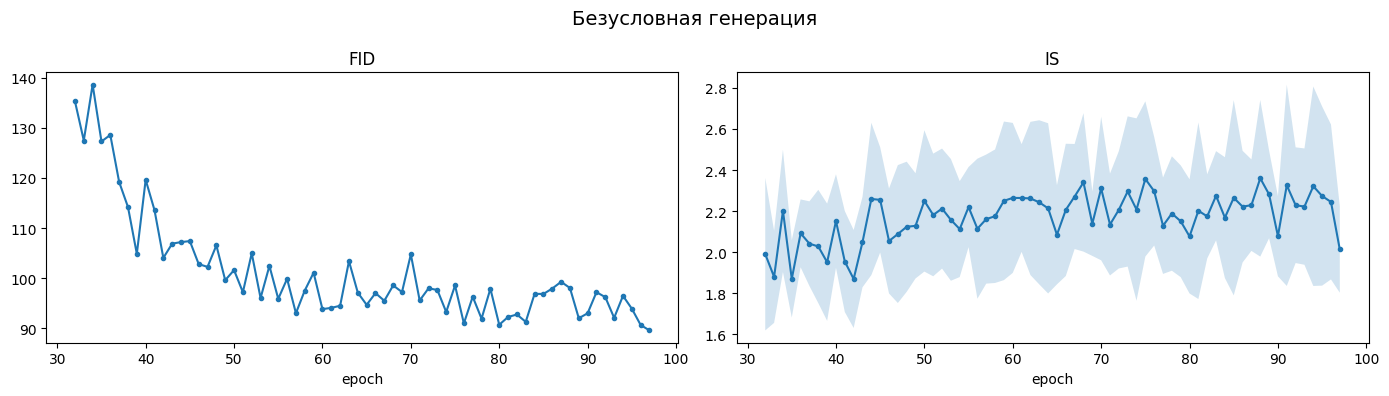

In [ ]:
def smooth(arr, window=200):
    if len(arr) < window:
        return arr
    kernel = np.ones(window) / window
    return np.convolve(arr, kernel, mode='valid')


def plot_losses(losses, title):
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    for ax, (key, label) in zip(axes.flatten(),
            [("crit", "Critic loss"), ("gen", "Generator loss"),
             ("wass", "Wasserstein distance"), ("gp", "Gradient penalty")]):
        ax.plot(smooth(losses[key]), linewidth=0.5)
        ax.set_title(label)
        ax.set_xlabel("step")
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


def plot_metrics(metrics, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(metrics["epoch"], metrics["fid"], marker='o', markersize=3)
    axes[0].set_title("FID")
    axes[0].set_xlabel("epoch")
    axes[1].plot(metrics["epoch"], metrics["is_mean"], marker='o', markersize=3)
    std = np.array(metrics["is_std"])
    if not np.all(np.isnan(std)):
        axes[1].fill_between(metrics["epoch"],
            np.array(metrics["is_mean"]) - std,
            np.array(metrics["is_mean"]) + std, alpha=0.2)
    axes[1].set_title("IS")
    axes[1].set_xlabel("epoch")
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()
    
plot_losses(losses, "Безусловная генерация")
plot_metrics(metrics, "Безусловная генерация")

### Графики для условной модели

Эта ячейка визуализирует динамику обучения условного генератора и критика. Сравнение с предыдущими графиками помогает понять, насколько полезным оказалось условие по классу.


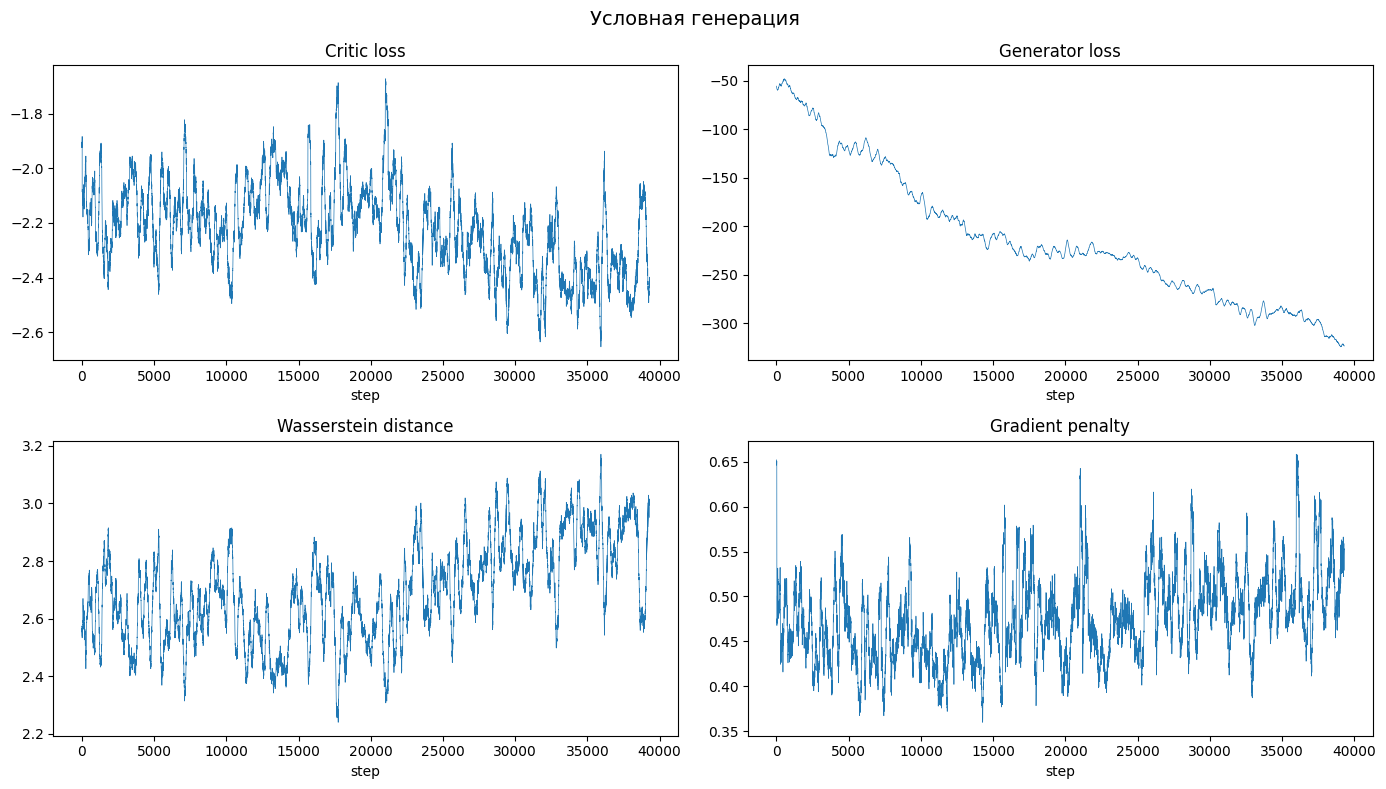

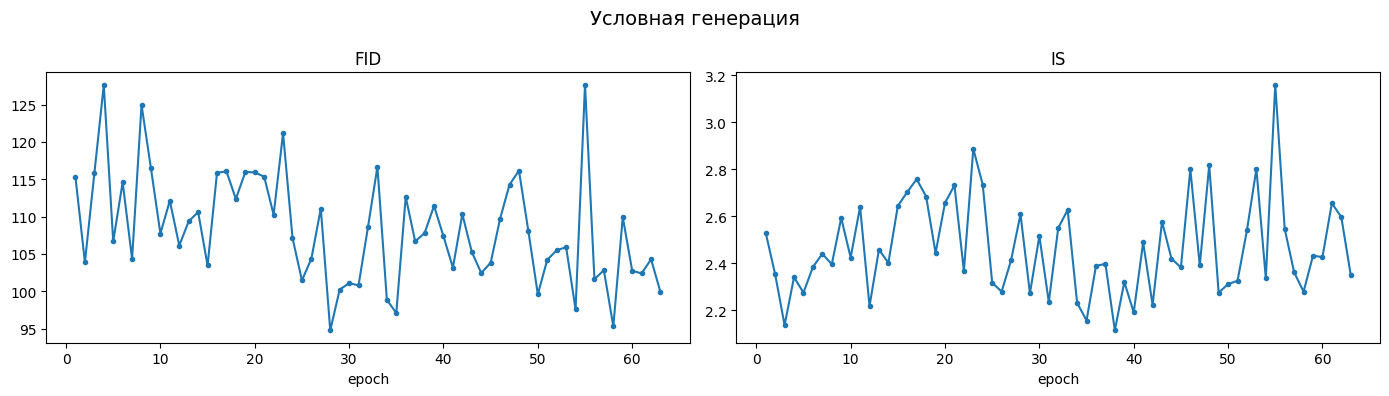

In [36]:
plot_losses(cond_losses, "Условная генерация")
plot_metrics(cond_metrics, "Условная генерация")

### Примеры безусловной генерации

Здесь модель переводится в режим инференса и генерирует набор новых изображений по случайному шуму. Полученная сетка позволяет визуально оценить качество безусловной генерации.


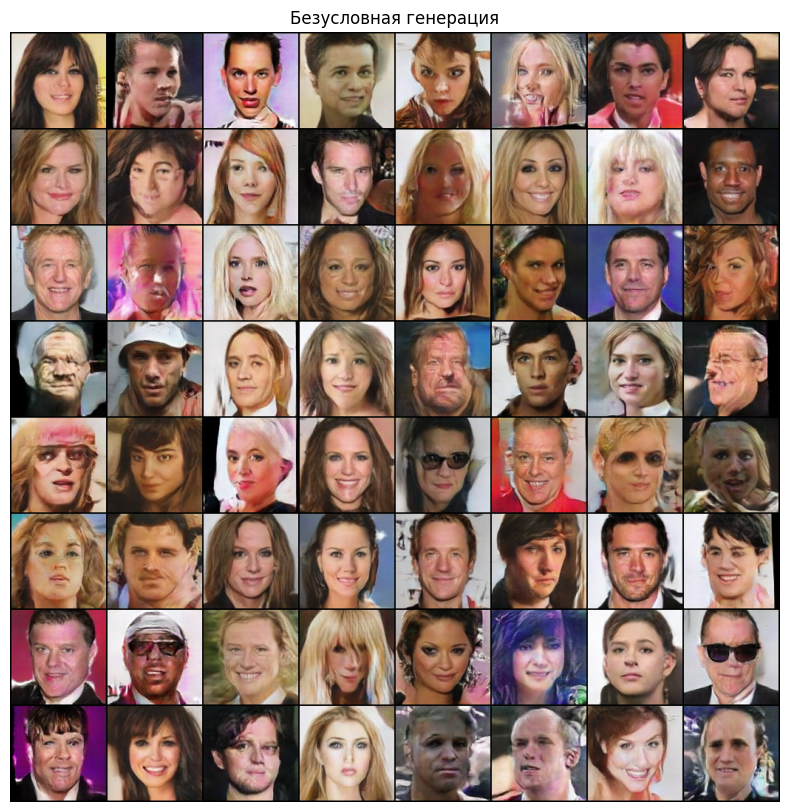

Generator(
  (net): Sequential(
    (0): ConvTranspose2d(128, 1024, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(1024, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): BatchNo

In [37]:
generator.eval()
with torch.inference_mode():
    z = torch.randn(64, 128, 1, 1, device="mps")
    fake = generator(z).cpu()
    fake = (fake * 0.5 + 0.5).clamp(0, 1)

grid = utils.make_grid(fake, nrow=8).permute(1, 2, 0).numpy()

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.imshow(grid)
ax.set_title("Безусловная генерация")
ax.axis("off")
plt.show()
generator.train()

### Примеры условной генерации

В этой ячейке условный генератор создаёт изображения для заранее заданных меток классов. Так можно проверить, действительно ли модель научилась управлять содержимым генерации.


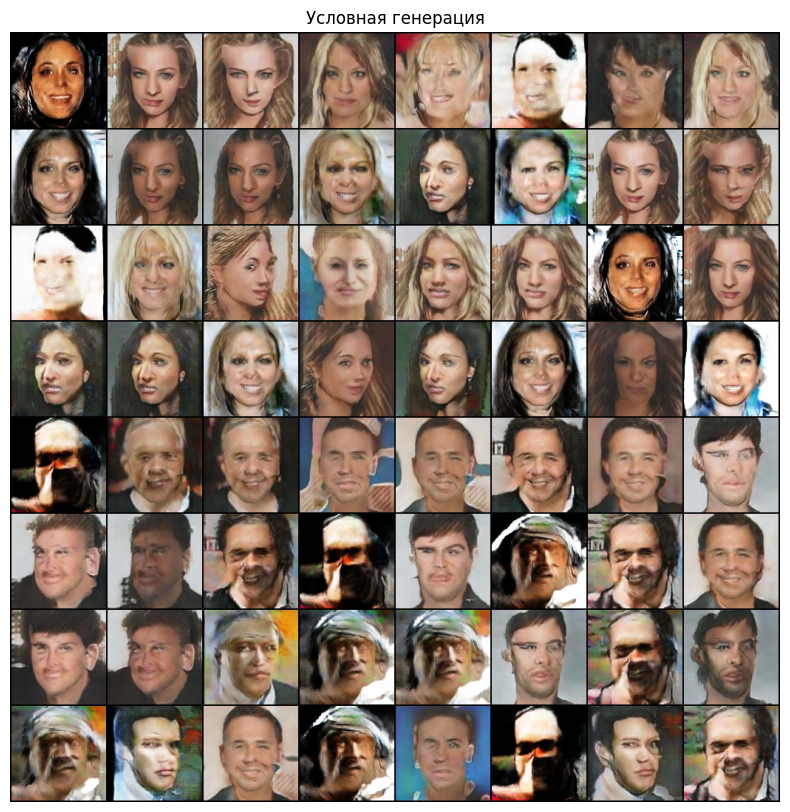

Generator(
  (y_emb): Embedding(2, 32)
  (net): Sequential(
    (0): ConvTranspose2d(160, 1024, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(1024, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), b

In [38]:
cond_generator.eval()
with torch.inference_mode():
    z = torch.randn(64, 128, 1, 1, device="mps")
    y = torch.tensor([0] * 32 + [1] * 32, device="mps")
    fake = cond_generator(z, y).cpu()
    fake = (fake * 0.5 + 0.5).clamp(0, 1)

grid = utils.make_grid(fake, nrow=8).permute(1, 2, 0).numpy()

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.imshow(grid)
ax.set_title("Условная генерация")
ax.axis("off")
plt.show()
cond_generator.train()

### Финальные функции оценки

Здесь повторно определяются и собираются вспомогательные функции для итогового вычисления `FID` и `Inception Score` на фиксированном числе примеров. Это отдельный этап финальной количественной оценки моделей.


In [39]:
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore

N_EVAL = 1024


def collect_real_features(loader, n_max):
    fid_m = FrechetInceptionDistance(feature=2048, normalize=True).to("cpu")
    n = 0
    for batch in loader:
        imgs = batch[0] if isinstance(batch, (tuple, list)) else batch
        fid_m.update(to_01(imgs).to("cpu", torch.float32), real=True)
        n += imgs.size(0)
        if n >= n_max:
            break
    return fid_m, n


@torch.inference_mode()
def eval_fid_is(generator, fid_m, n_eval, z_dim=128, y_dim=None):
    generator.eval()
    is_m = InceptionScore(normalize=True, splits=10).to("cpu")
    n = 0
    while n < n_eval:
        b = min(64, n_eval - n)
        z = torch.randn(b, z_dim, 1, 1, device="mps")
        if y_dim is not None:
            y = torch.randint(0, y_dim, (b,), device="mps")
            fake = generator(z, y)
        else:
            fake = generator(z)
        fake_01 = to_01(fake).to("cpu")
        fid_m.update(fake_01, real=False)
        is_m.update(fake_01)
        n += b
    fid = float(fid_m.compute().item())
    is_mean, is_std = is_m.compute()
    generator.train()
    return fid, float(is_mean), float(is_std)

### Итоговая оценка безусловной модели

В этой ячейке вычисляются финальные значения `FID` и `Inception Score` для безусловного WGAN-GP. Результат выводится в компактном виде для последующего сравнения.


In [40]:
fid_m, n_real = collect_real_features(val_loader, N_EVAL)
fid, is_mean, is_std = eval_fid_is(generator, fid_m, N_EVAL)
print(f"Безусловный WGAN-GP (n={N_EVAL}):  FID = {fid:.2f}  |  IS = {is_mean:.2f} ± {is_std:.2f}")

Безусловный WGAN-GP (n=1024):  FID = 47.52  |  IS = 2.68 ± 0.15


### Итоговая оценка условной модели

Здесь аналогичные итоговые метрики считаются для условного WGAN-GP. Это завершает эксперимент и позволяет напрямую сравнить оба подхода.


In [41]:
cond_fid_m, _ = collect_real_features(cond_val_loader, N_EVAL)
cond_fid, cond_is_mean, cond_is_std = eval_fid_is(cond_generator, cond_fid_m, N_EVAL, y_dim=2)
print(f"Условный WGAN-GP (n={N_EVAL}):  FID = {cond_fid:.2f}  |  IS = {cond_is_mean:.2f} ± {cond_is_std:.2f}")

Условный WGAN-GP (n=1024):  FID = 77.53  |  IS = 2.41 ± 0.14
